# TP5 - Clasificando informales con métodos de regularización Ridge y LASSO

In [23]:
## 0. Librerías y configuración

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.dpi']        = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = False
print('Librerías base cargadas.')

Librerías base cargadas.


In [2]:
#Rutas
RUTA_TP4 = r'C:\Users\juanc\OneDrive\Escritorio\SQL Training\Big Data y Machine Learning\TP4'
RUTA_OUT = os.getcwd()
RUTA_2024 = os.path.join(RUTA_TP4, 'usu_individual_T324.xlsx')
RUTA_2025 = os.path.join(RUTA_TP4, 'usu_individual_T325.xlsx')
print('Salida:', RUTA_OUT)

Salida: C:\Users\juanc


In [3]:
#Variables a seleccionar 

VARS = [
    'CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'PONDERA',
    'CH03', 'CH04', 'CH06', 'CH07', 'CH08',
    'NIVEL_ED', 'ESTADO', 'CAT_OCUP',
    'PP04C', 'PP04D_COD', 'PP07H',
    'PP3E_TOT', 'PP3F_TOT',
    'CH12', 'CH13', 'CH14',
]
eph_2024_raw = pd.read_excel(RUTA_2024)
eph_2025_raw = pd.read_excel(RUTA_2025)
print(f'EPH 2024 T3: {eph_2024_raw.shape[0]:,} personas | EPH 2025 T3: {eph_2025_raw.shape[0]:,} personas')

vars_2024 = [v for v in VARS if v in eph_2024_raw.columns]
vars_2025 = [v for v in VARS if v in eph_2025_raw.columns]
df_2024 = eph_2024_raw[vars_2024].copy(); df_2024['año'] = 2024
df_2025 = eph_2025_raw[vars_2025].copy(); df_2025['año'] = 2025
for df in [df_2024, df_2025]:
    df['CH08'] = pd.to_numeric(df['CH08'], errors='coerce').astype('Int64')
df_total = pd.concat([df_2024, df_2025], ignore_index=True)
print(f'Base total combinada: {len(df_total):,} personas')

EPH 2024 T3: 47,564 personas | EPH 2025 T3: 44,946 personas
Base total combinada: 92,510 personas


## Variables derivadas y características adicionales

| Variable | Fuente EPH | Descripción |
|----------|-----------|-------------|
| `edad`, `edad2` | CH06 | Edad y su cuadrado (perfil de ciclo de vida, forma de U) |
| `educ` | CH12/CH13/CH14 | Años de educación formal |
| `sec_completo` | educ≥12 | Dummy: secundario completo |
| `universitario` | educ≥17 | Dummy: universitario completo |
| `mujer` | CH04=2 | Dummy: mujer |
| `casado` | CH07∈{1,2} | Dummy: casado/unido |
| `jefe_hogar` | CH03=1 | Dummy: jefe/a de hogar |
| `nhogar` | conteo | Miembros del hogar |
| `horastrab` | PP3E_TOT+PP3F_TOT | Horas semanales (TODOS los ocupados) |
| `jornada_completa` | PP3E_TOT≥35 | Dummy: 35+ horas |
| `pluriempleo` | PP3F_TOT>0 | Dummy: segunda ocupación |
| `PP04C` | PP04C | Tamaño del establecimiento *(caveat: parte de la definición)* |
| `sin_cobertura` | CH08=4 | Dummy: sin obra social *(caveat: endógena a la formalidad)* |
| `sector_construccion` | CAES 41–43 | Dummy: construcción (alta informalidad) |
| `sector_comercio` | CAES 45–47 | Dummy: comercio |



In [5]:
# respondieron la condición de actividad
respondieron = df_total[df_total['ESTADO'] != 0].copy()

# edad y edad² 
respondieron['edad'] = pd.to_numeric(respondieron['CH06'], errors='coerce')
respondieron['edad'] = respondieron['edad'].where((respondieron['edad'] >= 0) & (respondieron['edad'] <= 120), np.nan)
respondieron['edad2'] = respondieron['edad'] ** 2

# educ: años de educación formal
años_base = {1:0, 2:0, 3:0, 4:7, 5:9, 6:12, 7:12, 8:17, 9:0}
años_max  = {1:1, 2:7, 3:9, 4:5, 5:3, 6:5,  7:5,  8:5,  9:0}
def calcular_educ(row):
    try:
        nivel    = int(pd.to_numeric(row.get('CH12', 0), errors='coerce') or 0)
        completo = int(pd.to_numeric(row.get('CH13', 2), errors='coerce') or 2)
        ultimo   = pd.to_numeric(row.get('CH14', 0), errors='coerce'); ultimo = 0 if pd.isna(ultimo) else int(ultimo)
        base = años_base.get(nivel, 0); maximo = años_max.get(nivel, 0)
        return base + maximo if completo == 1 else base + min(ultimo, maximo)
    except: return np.nan
respondieron['educ'] = respondieron.apply(calcular_educ, axis=1)
respondieron['sec_completo']  = (respondieron['educ'] >= 12).astype(float)
respondieron['universitario'] = (respondieron['educ'] >= 17).astype(float)

# horastrab para TODOS los ocupados (corrección del sesgo "solo jefes)
respondieron['PP3E_TOT'] = pd.to_numeric(respondieron['PP3E_TOT'], errors='coerce').replace(999, np.nan)
respondieron['PP3F_TOT'] = pd.to_numeric(respondieron['PP3F_TOT'], errors='coerce').replace(999, np.nan).fillna(0)
respondieron['horastrab'] = respondieron['PP3E_TOT'] + respondieron['PP3F_TOT']
respondieron['jornada_completa'] = (respondieron['PP3E_TOT'] >= 35).astype(float)
respondieron['pluriempleo']      = (respondieron['PP3F_TOT'] > 0).astype(float)

# dummies demográficas 
respondieron['mujer']      = (pd.to_numeric(respondieron['CH04'], errors='coerce') == 2).astype(float)
respondieron['casado']     = (pd.to_numeric(respondieron['CH07'], errors='coerce').isin([1, 2])).astype(float)
respondieron['jefe_hogar'] = (pd.to_numeric(respondieron['CH03'], errors='coerce') == 1).astype(float)
respondieron['sin_cobertura'] = (pd.to_numeric(respondieron['CH08'], errors='coerce') == 4).astype(float)

# nhogar 
nh = respondieron.groupby(['CODUSU', 'NRO_HOGAR'])['COMPONENTE'].count().reset_index().rename(columns={'COMPONENTE': 'nhogar'})
respondieron = respondieron.merge(nh, on=['CODUSU', 'NRO_HOGAR'], how='left')

# dummies de sector 
code = pd.to_numeric(respondieron['PP04D_COD'], errors='coerce')
div = pd.Series(np.nan, index=respondieron.index)
ok = code.notna()
div.loc[ok] = code.loc[ok].astype('int64').astype(str).str[:2].astype(int)
respondieron['caes_div'] = div
respondieron['sector_construccion'] = respondieron['caes_div'].isin([41, 42, 43]).astype(float)
respondieron['sector_comercio']     = respondieron['caes_div'].isin([45, 46, 47]).astype(float)

print('Variables derivadas y adicionales creadas.')

Variables derivadas y adicionales creadas.


## (Upper-tier informal)

In [26]:
# Formal (0):** asalariado (`CAT_OCUP=3`) con descuento jubilatorio (`PP07H=1`)
# Informal (1):** asalariado (`CAT_OCUP=3`) + sin jubilación (`PP07H=2`) + empresa > 5 (`PP04C≥6`)
# **NaN:** no aplica

def crear_indicador_informalidad(df):
    df = df.copy()
    for col in ['CAT_OCUP', 'PP07H', 'PP04C']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    def clasificar(row):
        if row.get('CAT_OCUP', np.nan) != 3: return np.nan
        if row.get('PP07H', np.nan) not in [1, 2]: return np.nan
        if row.get('PP07H', np.nan) == 1: return 0
        pp04c = row.get('PP04C', np.nan)
        if pd.isna(pp04c) or pp04c == 99: return np.nan
        return 1 if pp04c >= 6 else 0
    df['informal'] = df.apply(clasificar, axis=1)
    return df

ocupados = respondieron[respondieron['ESTADO'] == 1].copy()
ocupados = crear_indicador_informalidad(ocupados)
print(f'Ocupados (2024+2025): {len(ocupados):,}')
print(ocupados[ocupados['informal'].notna()].groupby(['año','informal']).size()
      .rename({0:'Formal',1:'Upper-tier informal'}).unstack())

Ocupados (2024+2025): 41,097
informal  Formal  Upper-tier informal
año                                  
2024       12871                 1602
2025       12102                 1443


## Matriz X de 16 variables y separación train/test

ocupados_X_2024 (train), ocupados_X_2025 (test) y ocupados_X_2025_MM

In [7]:
VARS_X = [
    'edad', 'edad2', 'educ', 'sec_completo', 'universitario',
    'mujer', 'casado', 'jefe_hogar', 'nhogar',
    'horastrab', 'jornada_completa', 'pluriempleo', 'PP04C',
    'sin_cobertura',
    'sector_construccion', 'sector_comercio',
]
assert len(VARS_X) == 16, len(VARS_X)
print(f'Matriz X: {len(VARS_X)} variables (>15, ninguna de ingreso)')
for i, v in enumerate(VARS_X, 1): print(f'  {i:2d}. {v}')

Matriz X: 16 variables (>15, ninguna de ingreso)
   1. edad
   2. edad2
   3. educ
   4. sec_completo
   5. universitario
   6. mujer
   7. casado
   8. jefe_hogar
   9. nhogar
  10. horastrab
  11. jornada_completa
  12. pluriempleo
  13. PP04C
  14. sin_cobertura
  15. sector_construccion
  16. sector_comercio


In [8]:
# Asalariados con indicador definido 
asal = ocupados[(ocupados['CAT_OCUP'] == 3) & (ocupados['informal'].notna())].copy()
asal_2024 = asal[asal['año'] == 2024].copy()
asal_2025 = asal[asal['año'] == 2025].copy()

cols = VARS_X + ['informal', 'CODUSU', 'NRO_HOGAR', 'COMPONENTE']
a24 = asal_2024[cols].dropna().reset_index(drop=True)
a25 = asal_2025[cols].dropna().reset_index(drop=True)

ocupados_X_2024 = a24[VARS_X].copy(); y_2024 = a24['informal'].copy()
ocupados_X_2025 = a25[VARS_X].copy(); y_2025 = a25['informal'].copy()
print(f'ocupados_X_2024: {ocupados_X_2024.shape} | informales: {int(y_2024.sum())}')
print(f'ocupados_X_2025: {ocupados_X_2025.shape} | informales: {int(y_2025.sum())}')

# Inner join MM: informalidad del año anterior
j24 = a24[['CODUSU','NRO_HOGAR','COMPONENTE','informal']].rename(columns={'informal':'informal_2024'})
j25 = a25[VARS_X + ['informal','CODUSU','NRO_HOGAR','COMPONENTE']]
ocupados_X_2025_MM = j25.merge(j24, on=['CODUSU','NRO_HOGAR','COMPONENTE'], how='inner').drop(
    columns=['CODUSU','NRO_HOGAR','COMPONENTE'])
print(f'ocupados_X_2025_MM: {ocupados_X_2025_MM.shape} (match {len(ocupados_X_2025_MM)/len(a25)*100:.1f}%)')

VARS_X_MM = VARS_X + ['informal_2024']

ocupados_X_2024: (14463, 16) | informales: 1601
ocupados_X_2025: (13528, 16) | informales: 1443
ocupados_X_2025_MM: (4435, 18) (match 32.8%)


In [9]:
# Guardamos la base 
e24 = ocupados_X_2024.copy(); e24['y_informal'] = y_2024.values
e25 = ocupados_X_2025.copy(); e25['y_informal'] = y_2025.values
e24.to_csv(os.path.join(RUTA_OUT, 'base_X_2024_16vars.csv'), index=False)
e25.to_csv(os.path.join(RUTA_OUT, 'base_X_2025_16vars.csv'), index=False)
ocupados_X_2025_MM.to_csv(os.path.join(RUTA_OUT, 'base_X_2025_MM_16vars.csv'), index=False)
print('Base ampliada guardada: base_X_2024_16vars.csv, base_X_2025_16vars.csv, base_X_2025_MM_16vars.csv')

Base ampliada guardada: base_X_2024_16vars.csv, base_X_2025_16vars.csv, base_X_2025_MM_16vars.csv



## Inciso A —  Tabla de diferencia de medias 2024 vs 2025

In [27]:
from scipy import stats
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
print('Librerías de regularización cargadas.')

Librerías de regularización cargadas.


In [11]:
filas = []
for var in VARS_X:
    x24 = ocupados_X_2024[var].dropna(); x25 = ocupados_X_2025[var].dropna()
    t, p = stats.ttest_ind(x24, x25, equal_var=False)
    sig = '*** (p<0.01)' if p<0.01 else ('** (p<0.05)' if p<0.05 else ('* (p<0.10)' if p<0.10 else 'No sig.'))
    filas.append({'Variable':var,'Media 2024':x24.mean(),'Media 2025':x25.mean(),
                  'Dif (25-24)':x25.mean()-x24.mean(),'p-valor':p,'Sig.':sig})
print('=== Inciso A: diferencia de medias (Welch t-test) ===\n')
print(pd.DataFrame(filas).set_index('Variable').round(4).to_string())
print(f'\nN — 2024: {len(ocupados_X_2024):,} | 2025: {len(ocupados_X_2025):,}')

=== Inciso A: diferencia de medias (Welch t-test) ===

                     Media 2024  Media 2025  Dif (25-24)  p-valor          Sig.
Variable                                                                       
edad                    40.3992     40.6211       0.2219   0.1344       No sig.
edad2                1,784.1803  1,804.8819      20.7016   0.1015       No sig.
educ                    12.7574     12.7188      -0.0386   0.3724       No sig.
sec_completo             0.7529      0.7555       0.0026   0.6159       No sig.
universitario            0.2771      0.2697      -0.0075   0.1618       No sig.
mujer                    0.4749      0.4783       0.0033   0.5771       No sig.
casado                   0.5300      0.5230      -0.0071   0.2376       No sig.
jefe_hogar               0.4958      0.4874      -0.0084   0.1609       No sig.
nhogar                   5.0351      5.1402       0.1050   0.0085  *** (p<0.01)
horastrab               36.9047     37.3437       0.4390   0.0226

## Inciso B - Regularización Ridge y LASSO

In [12]:
### Coeficientes en función de la grilla de λ

VARS_NUM = ['edad', 'edad2', 'educ', 'nhogar', 'horastrab', 'PP04C']
VARS_DUM = [v for v in VARS_X if v not in VARS_NUM]
assert len(VARS_NUM) + len(VARS_DUM) == len(VARS_X)

scaler = StandardScaler()
scaler.fit(ocupados_X_2024[VARS_NUM])  # fit solo con 2024 (sin leakage)

def estandarizar(df):
    """Escala las numéricas y concatena las dummies sin tocar; conserva el orden VARS_X."""
    num = pd.DataFrame(scaler.transform(df[VARS_NUM]), columns=VARS_NUM, index=df.index)
    dum = df[VARS_DUM].reset_index(drop=True)
    num = num.reset_index(drop=True)
    return pd.concat([num, dum], axis=1)[VARS_X]

X24s = estandarizar(ocupados_X_2024)
X25s = estandarizar(ocupados_X_2025)
# Base MM: numéricas escaladas + dummies 0/1; informal_2024 queda 0/1 aparte
XMMs = estandarizar(ocupados_X_2025_MM[VARS_X])
XMMs['informal_2024'] = ocupados_X_2025_MM['informal_2024'].values
y_2025_MM = ocupados_X_2025_MM['informal'].values
print('Estandarizacion OK (solo numericas):', X24s.shape, X25s.shape, XMMs.shape)
print('  Numericas escaladas:', VARS_NUM)
print('  Dummies sin escalar:', VARS_DUM)

Estandarizacion OK (solo numericas): (14463, 16) (13528, 16) (4435, 17)
  Numericas escaladas: ['edad', 'edad2', 'educ', 'nhogar', 'horastrab', 'PP04C']
  Dummies sin escalar: ['sec_completo', 'universitario', 'mujer', 'casado', 'jefe_hogar', 'jornada_completa', 'pluriempleo', 'sin_cobertura', 'sector_construccion', 'sector_comercio']


In [13]:
ns = np.arange(-5, 6); lambdas = 10.0**ns; Cs = 1.0/lambdas
coefs_ridge, coefs_lasso = [], []
for C in Cs:
    mr = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=2000, random_state=42).fit(X24s, y_2024)
    coefs_ridge.append(mr.coef_[0])
    ml = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=5000, random_state=42).fit(X24s, y_2024)
    coefs_lasso.append(ml.coef_[0])
coefs_ridge = np.array(coefs_ridge); coefs_lasso = np.array(coefs_lasso)
print('Coeficientes estimados para', len(Cs), 'valores de lambda. Forma:', coefs_ridge.shape)

Coeficientes estimados para 11 valores de lambda. Forma: (11, 16)


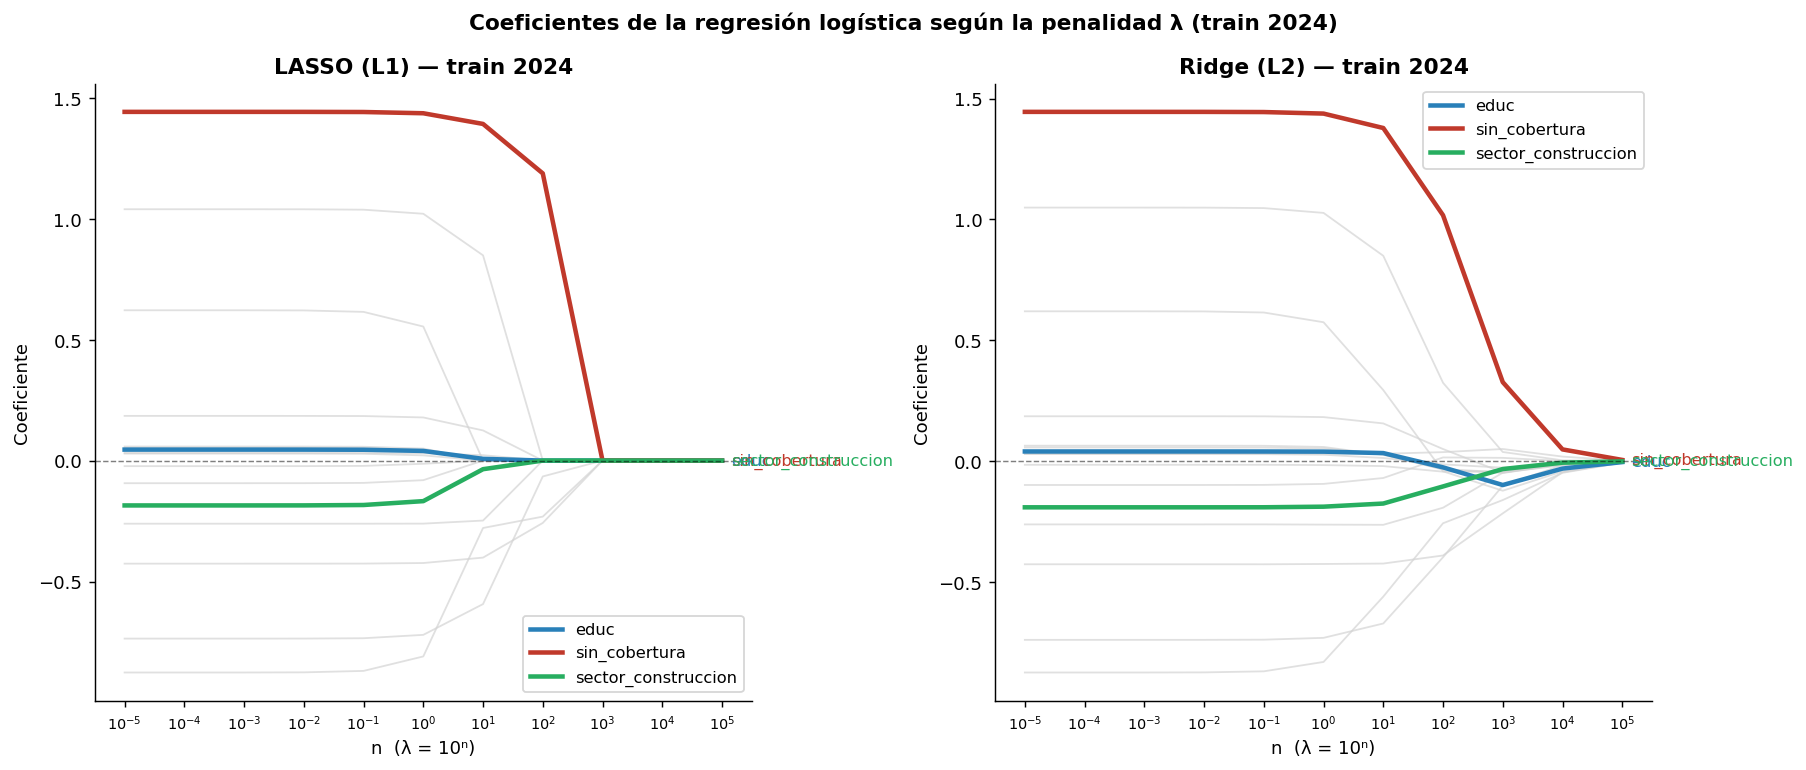

Guardado: TP5_B1_coefs_grilla.png


In [14]:
# Etiquetamos 3 predictores relevantes (NINGUNO de ingreso)
VARS_ETIQ = ['educ', 'sin_cobertura', 'sector_construccion']
idx = [VARS_X.index(v) for v in VARS_ETIQ]; colores = ['#2980B9','#C0392B','#27AE60']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coefs, tit in zip(axes, [coefs_lasso, coefs_ridge],
        ['LASSO (L1) — train 2024','Ridge (L2) — train 2024']):
    for j in range(len(VARS_X)):
        if j not in idx: ax.plot(ns, coefs[:, j], color='lightgray', lw=1, alpha=0.7)
    for j, v, c in zip(idx, VARS_ETIQ, colores):
        ax.plot(ns, coefs[:, j], color=c, lw=2.5, label=v)
        ax.annotate(v, xy=(ns[-1], coefs[-1, j]), xytext=(5,0), textcoords='offset points',
                    fontsize=9, color=c, va='center')
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('n  (λ = 10ⁿ)'); ax.set_ylabel('Coeficiente'); ax.set_title(tit, fontweight='bold')
    ax.set_xticks(ns); ax.set_xticklabels([f'$10^{{{n}}}$' for n in ns], fontsize=8); ax.legend(fontsize=9)
fig.suptitle('Coeficientes de la regresión logística según la penalidad λ (train 2024)', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(RUTA_OUT,'TP5_B1_coefs_grilla.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Guardado: TP5_B1_coefs_grilla.png')

### B.2 - Penalidad óptima por cross-validation (5-fold) sobre ocupados_X_2025_MM

In [15]:
ridge_cv = LogisticRegressionCV(Cs=Cs, cv=5, penalty='l2', solver='lbfgs',
        max_iter=2000, random_state=42, scoring='accuracy').fit(XMMs, y_2025_MM)
lasso_cv = LogisticRegressionCV(Cs=Cs, cv=5, penalty='l1', solver='saga',
        max_iter=5000, random_state=42, scoring='accuracy').fit(XMMs, y_2025_MM)
# lambda optimo = el que minimiza el error medio de CV sobre la grilla (consistente
# con el grafico B.2). Se deriva del argmin del error, no de C_, porque con clases
# desbalanceadas y accuracy hay empates que pueden desincronizar el atributo C_.
err_ridge = 1 - ridge_cv.scores_[1].mean(axis=0)
err_lasso = 1 - lasso_cv.scores_[1].mean(axis=0)
n_r = ns[np.argmin(err_ridge)]; lam_r = 10.0**n_r; C_r = 1.0/lam_r
n_l = ns[np.argmin(err_lasso)]; lam_l = 10.0**n_l; C_l = 1.0/lam_l
print(f'Ridge CV -> lambda optimo = 10^{n_r:.0f} (error CV minimo = {err_ridge.min():.4f})')
print(f'LASSO CV -> lambda optimo = 10^{n_l:.0f} (error CV minimo = {err_lasso.min():.4f})')

Ridge CV -> lambda optimo = 10^-5 (error CV minimo = 0.0728)
LASSO CV -> lambda optimo = 10^-5 (error CV minimo = 0.0731)


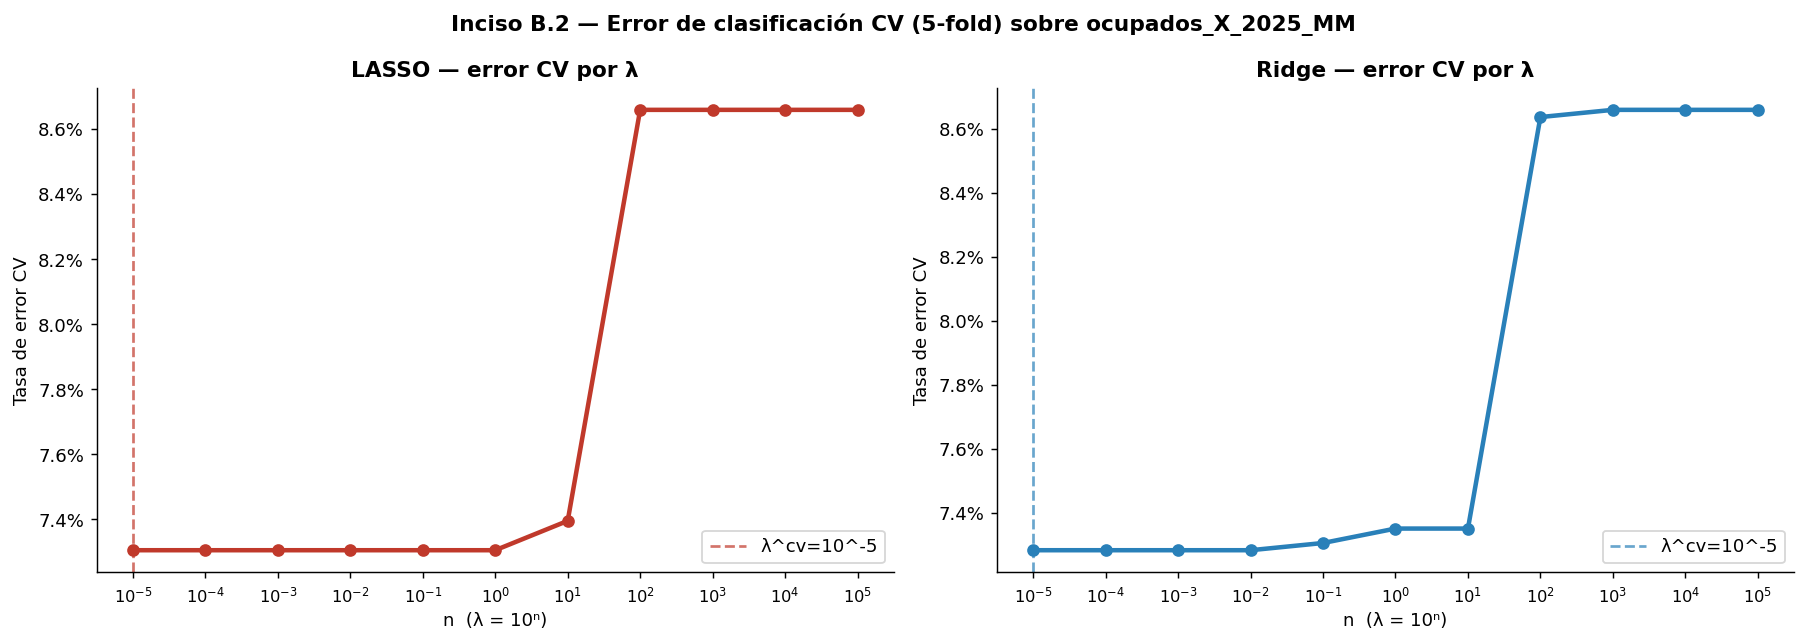

Guardado: TP5_B2_cv_error.png


In [16]:
er = 1 - ridge_cv.scores_[1].mean(axis=0); el = 1 - lasso_cv.scores_[1].mean(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ns, el, 'o-', color='#C0392B', lw=2.5); axes[0].axvline(n_l, color='#C0392B', ls='--', alpha=0.7,
    label=f'λ^cv=10^{n_l:.0f}')
axes[0].set_title('LASSO — error CV por λ', fontweight='bold')
axes[1].plot(ns, er, 'o-', color='#2980B9', lw=2.5); axes[1].axvline(n_r, color='#2980B9', ls='--', alpha=0.7,
    label=f'λ^cv=10^{n_r:.0f}')
axes[1].set_title('Ridge — error CV por λ', fontweight='bold')
for ax in axes:
    ax.set_xlabel('n  (λ = 10ⁿ)'); ax.set_ylabel('Tasa de error CV')
    ax.set_xticks(ns); ax.set_xticklabels([f'$10^{{{n}}}$' for n in ns], fontsize=9); ax.legend()
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
fig.suptitle('Inciso B.2 — Error de clasificación CV (5-fold) sobre ocupados_X_2025_MM', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(RUTA_OUT,'TP5_B2_cv_error.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Guardado: TP5_B2_cv_error.png')

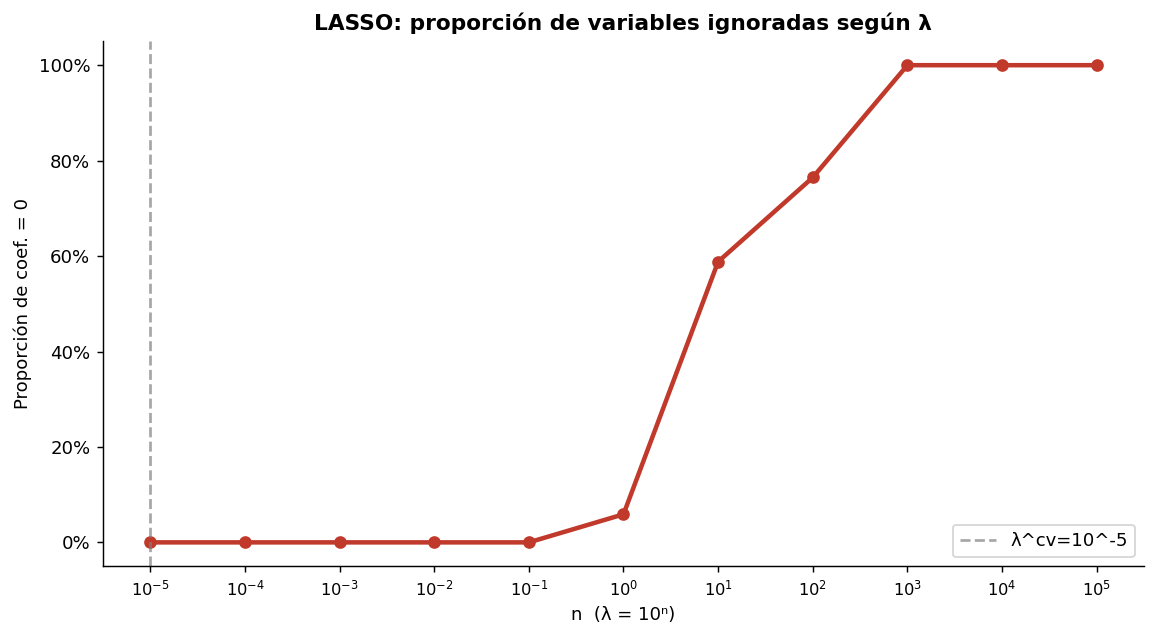

Guardado: TP5_B2_lasso_ceros.png


In [17]:
# proporción de coeficientes en cero (LASSO) por λ
prop0 = []
for C in Cs:
    m = LogisticRegression(penalty='l1', C=C, solver='saga', max_iter=5000, random_state=42).fit(XMMs, y_2025_MM)
    prop0.append(np.mean(np.isclose(m.coef_[0], 0, atol=1e-6)))
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(ns, prop0, 'o-', color='#C0392B', lw=2.5); ax.axvline(n_l, color='gray', ls='--', alpha=0.7,
    label=f'λ^cv=10^{n_l:.0f}')
ax.set_xlabel('n  (λ = 10ⁿ)'); ax.set_ylabel('Proporción de coef. = 0')
ax.set_title('LASSO: proporción de variables ignoradas según λ', fontweight='bold')
ax.set_xticks(ns); ax.set_xticklabels([f'$10^{{{n}}}$' for n in ns], fontsize=9)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0)); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(RUTA_OUT,'TP5_B2_lasso_ceros.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Guardado: TP5_B2_lasso_ceros.png')

### B3 - Estimación con λ^cv y comparación de coeficientes 

In [18]:
Xsm = sm.add_constant(XMMs); Ysm = pd.Series(y_2025_MM, name='informal').astype(float)
logit_sin = sm.Logit(Ysm, Xsm).fit(disp=False, maxiter=200)
print('=== Logit sin penalidad (ocupados_X_2025_MM) ==='); print(logit_sin.summary2())

=== Logit sin penalidad (ocupados_X_2025_MM) ===
                           Results: Logit
Model:                Logit            Method:           MLE        
Dependent Variable:   informal         Pseudo R-squared: 0.366      
Date:                 2026-06-12 10:09 AIC:              1693.6309  
No. Observations:     4435             BIC:              1808.7820  
Df Model:             17               Log-Likelihood:   -828.82    
Df Residuals:         4417             LL-Null:          -1306.4    
Converged:            1.0000           LLR p-value:      3.5239e-192
No. Iterations:       9.0000           Scale:            1.0000     
--------------------------------------------------------------------
                     Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------
const               -3.4812   0.3343 -10.4143 0.0000 -4.1363 -2.8260
edad                -1.4262   0.4295  -3.3206 0.0009 -2.2680 -0.5844
edad2       

In [20]:
lasso_opt = LogisticRegression(penalty='l1', C=C_l, solver='saga', max_iter=5000, random_state=42).fit(XMMs, y_2025_MM)
ridge_opt = LogisticRegression(penalty='l2', C=C_r, solver='lbfgs', max_iter=2000, random_state=42).fit(XMMs, y_2025_MM)
cols = list(XMMs.columns)
tabla = pd.DataFrame({
    'Sin penalidad': logit_sin.params.drop('const'),
    f'L1 LASSO (λ=10^{n_l:.0f})': pd.Series(lasso_opt.coef_[0], index=cols),
    f'L2 Ridge (λ=10^{n_r:.0f})': pd.Series(ridge_opt.coef_[0], index=cols),
})
tabla['LASSO=0'] = pd.Series(np.isclose(lasso_opt.coef_[0], 0, atol=1e-6), index=cols).map(
    {True:'Sí (excluida)', False:'No'})
print('=== Inciso B.3: comparación de coeficientes (X estandarizada) ===\n')
print(tabla.round(4).to_string())

=== Inciso B.3: comparación de coeficientes (X estandarizada) ===

                     Sin penalidad  L1 LASSO (λ=10^-5)  L2 Ridge (λ=10^-5) LASSO=0
edad                       -1.4262             -1.4230             -1.4222      No
edad2                       1.1455              1.1423              1.1417      No
educ                       -0.1140             -0.1139             -0.1132      No
sec_completo               -0.0462             -0.0464             -0.0457      No
universitario               0.5603              0.5600              0.5581      No
mujer                      -0.4095             -0.4096             -0.4116      No
casado                      0.0267              0.0265              0.0268      No
jefe_hogar                  0.0546              0.0544              0.0527      No
nhogar                     -0.0414             -0.0414             -0.0419      No
horastrab                   0.1181              0.1181              0.1178      No
jornada_completa    

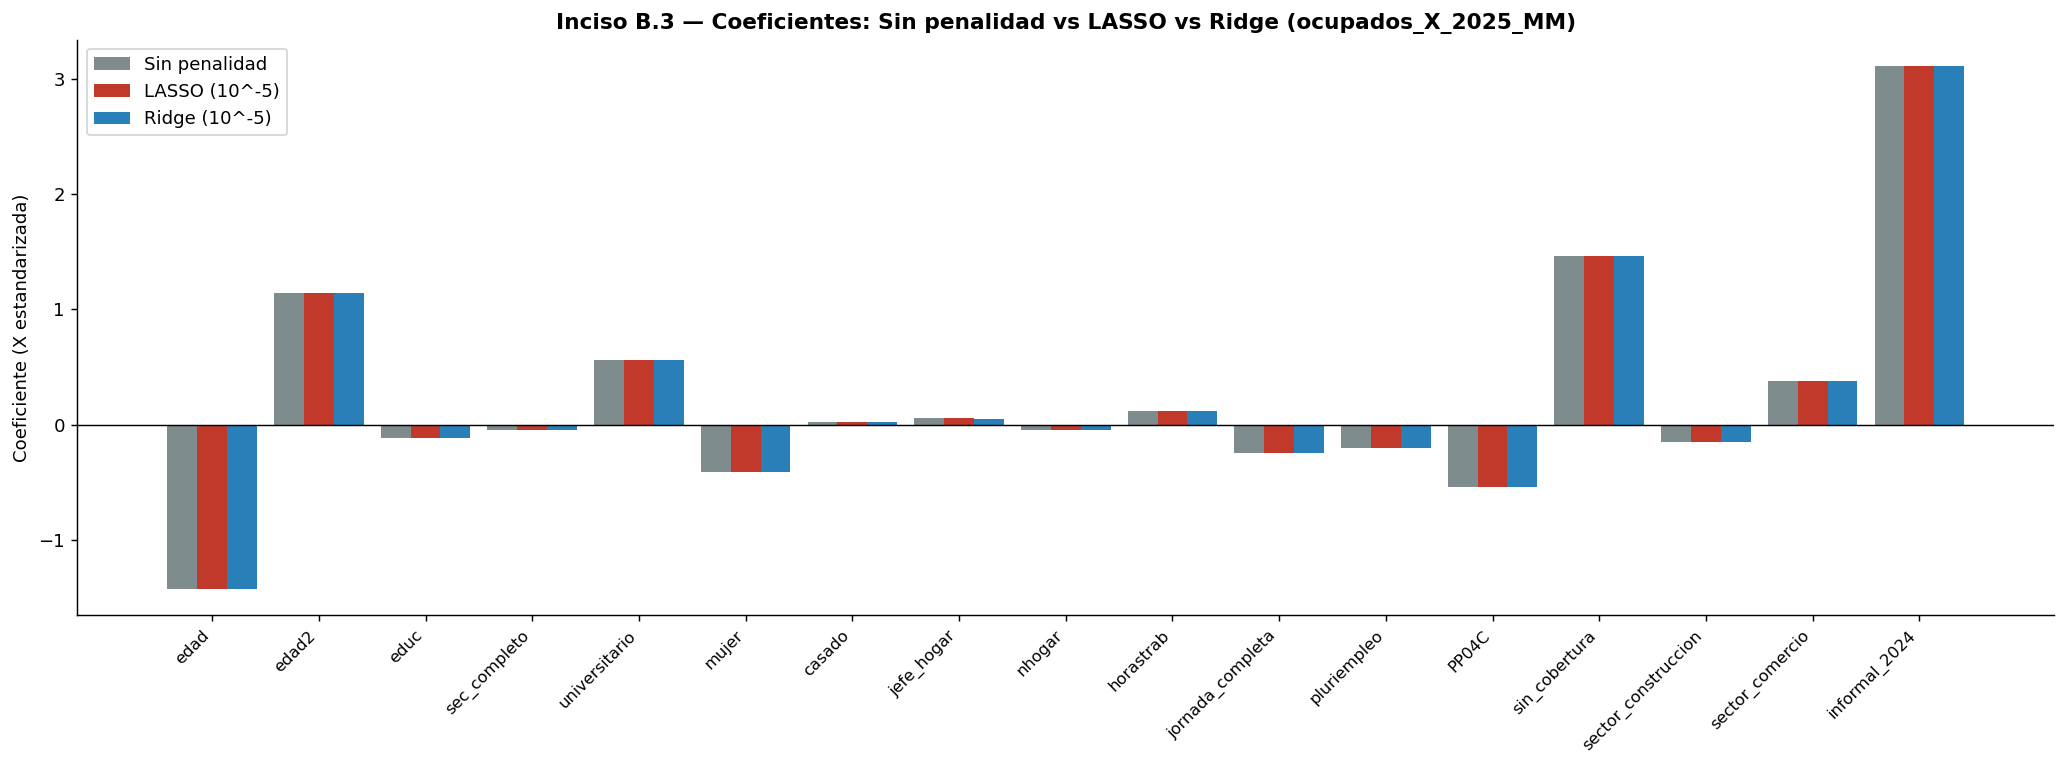

Guardado: TP5_B3_comparacion_coefs.png


In [21]:
x = np.arange(len(cols)); w = 0.28
fig, ax = plt.subplots(figsize=(16,6))
ax.bar(x-w, logit_sin.params.drop('const').values, w, label='Sin penalidad', color='#7F8C8D')
ax.bar(x,   lasso_opt.coef_[0], w, label=f'LASSO (10^{n_l:.0f})', color='#C0392B')
ax.bar(x+w, ridge_opt.coef_[0], w, label=f'Ridge (10^{n_r:.0f})', color='#2980B9')
ax.axhline(0, color='black', lw=0.8); ax.set_xticks(x); ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Coeficiente (X estandarizada)'); ax.legend()
ax.set_title('Inciso B.3 — Coeficientes: Sin penalidad vs LASSO vs Ridge (ocupados_X_2025_MM)', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(RUTA_OUT,'TP5_B3_comparacion_coefs.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Guardado: TP5_B3_comparacion_coefs.png')